In [3]:
import os
import sys
import numpy as np
from gen_graph import gen_plots

# custom imports
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from cnn_host import train_cnn
from data_proc.parse_audio_data import parse_audio, save_audio

import pickle
import matplotlib.pyplot as plt

N = 30000
with open("../data/train_set.pickle", "rb") as f:
    train_set = pickle.load(f)

with open("../data/test_set.pickle", "rb") as f:
    test_set = pickle.load(f)

train_x = [i[0] for i in train_set]
train_y = [i[1] for i in train_set]

weights, bia, loss_hist = train_cnn(train_x, train_y, N, lr=1e-6, epochs=100)


Reverse differentiation of function rev_cnn_loss:
def rev_cnn_loss(noisy : In[Array[float]], _dnoisy_AwWihn : Out[Array[float]], clean : In[Array[float]], _dclean_inNJAk : Out[Array[float]], weights : In[Array[float]], _dweights_tAtcCq : Out[Array[float]], bias : In[float], _dbias_t6fS3x : Out[float], N : In[int], _dN_9kt5AS : Out[int], K : In[int], _dK_htxFeV : Out[int], _dreturn_v0MZ4c : In[float]) -> void:
	_t_float_cjeBXs : Array[float, 1230000]
	_stack_ptr_float_cjeBXs : int = (int)(0)
	_t_int_cckkCY : Array[int, 1200000]
	_stack_ptr_int_cckkCY : int = (int)(0)
	_loop_var_0_QpOs6u : int
	_loop_var_1_et1Phj : int
	_loop_var_1_et1Phj_stack : Array[int, 30000]
	_loop_var_1_et1Phj_stack_ptr : int
	loss : float = (float)(0.0)
	_dloss_E8gDDa : float
	i : int = (K) - ((int)(1))
	sum : float = (float)(0.0)
	_dsum_Yf9oAQ : float
	j : int = (int)(0)
	diff : float = (float)(0.0)
	_ddiff_s1Ws8z : float
	_loop_var_0_QpOs6u = (int)(0)
	while (i) < (N) :
		(_t_float_cjeBXs)[_stack_ptr_float_cje

training...:   1%|          | 1/100 [00:00<01:29,  1.11it/s]

Epoch 0 | Loss: 7820.1981


training...:  11%|█         | 11/100 [00:09<01:18,  1.13it/s]

Epoch 10 | Loss: 86.5033


...

Epoch 80 | Loss: 86.4289


training...:  91%|█████████ | 91/100 [01:20<00:07,  1.14it/s]

Epoch 90 | Loss: 86.5158


training...: 100%|██████████| 100/100 [01:28<00:00,  1.13it/s]

final loss: 86.52851374409416


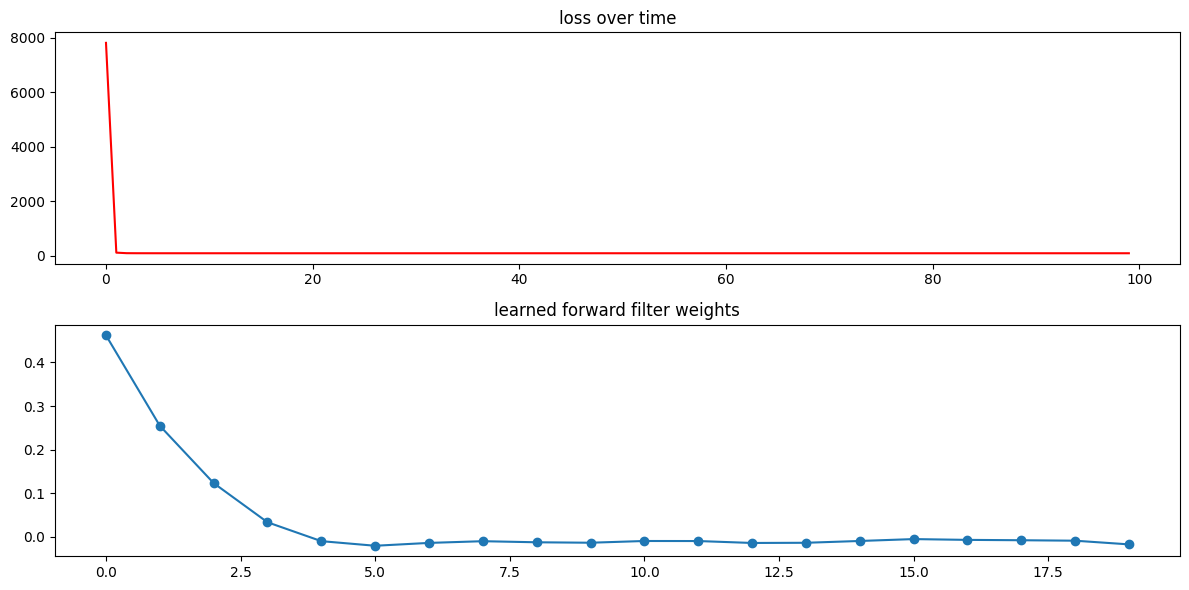

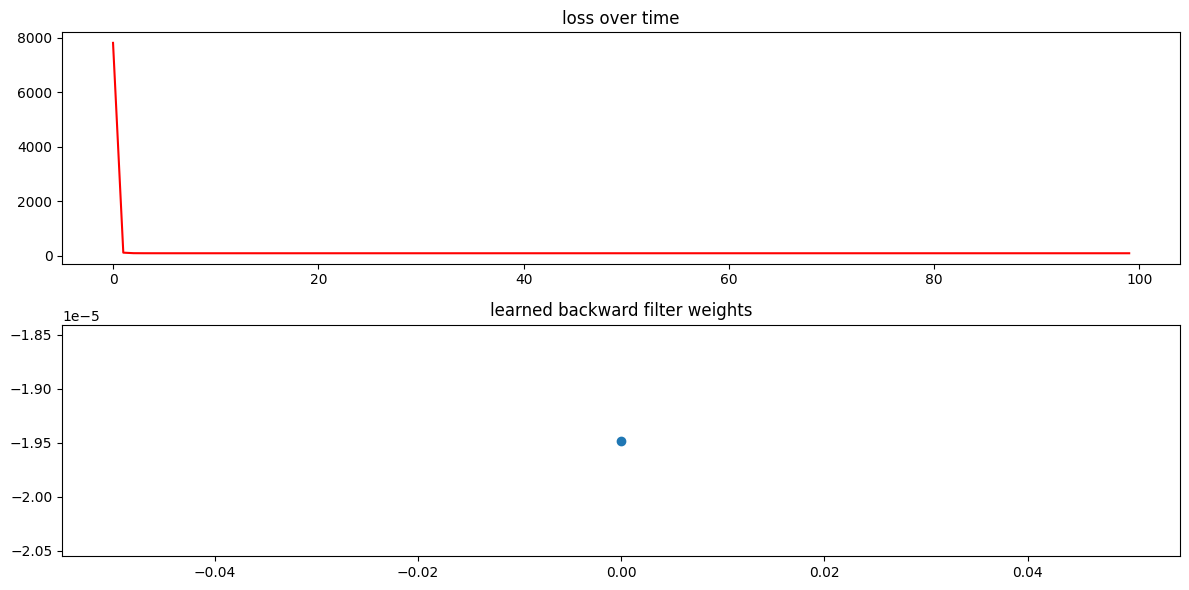

In [5]:
gen_plots(weights, loss_hist, "learned forward filter weights")
gen_plots(bia, loss_hist, "learned backward filter weights")

(160000,)
saved audio to: ../data/generated/cnn_gen.wav


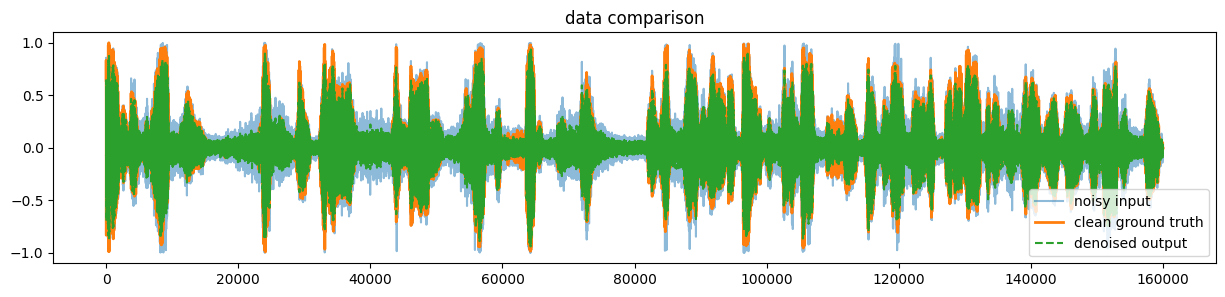

In [22]:
import random

# peak at some samples
def peak_sample_perf(noisy_sample, clean_sample, weights, bias):
    plt.figure(figsize=(15, 3))
    # example for one data snippet
    linear_sum = np.convolve(noisy_sample, weights, mode='full')
    linear_sum = linear_sum + bias
    denoised_audio = linear_sum

    save_audio(denoised_audio, 16000, output_path="../data/generated/cnn_gen.wav")

    plt.title("data comparison")
    plt.plot(noisy_sample, label="noisy input", alpha=0.5)
    plt.plot(clean_sample, label="clean ground truth", linewidth=2)
    plt.plot(denoised_audio, label="denoised output", linestyle='--')
    plt.legend()

    plt.show()

test_x = [i[0] for i in test_set]
test_y = [i[1] for i in test_set]

noise = f"../data/noise_speech_data/american_accent_15.wav"
clean = f"../data/speech_data/american_accent_15.wav"

noise, clean = parse_audio(clean, noise, max_n=None)

peak_sample_perf(noise, clean, weights, bia)

In [15]:
# calc average test set MSE
def calc_loss(eval_x, eval_y, weights, bias):
    K = 20
    total_mse = 0.0
    for x, y in zip(eval_x, eval_y):
        linear_sum = np.convolve(x, weights, mode='full')
        linear_sum = linear_sum[:len(x)]
        linear_sum = linear_sum + bias

        denoised_audio = linear_sum[K-1:]
        valid_y = y[K-1:]
        
        mse = np.sum((denoised_audio - valid_y) ** 2)
        total_mse += mse

    # Return the average MSE across all files in the dataset
    return total_mse / len(eval_x)

print(calc_loss(test_x, test_y, weights, bia))
print(calc_loss(train_x, train_y, weights, bia))

101.4327
86.522095
